In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
from matplotlib.gridspec import GridSpec
import matplotlib.image as image

In [2]:
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, 'utils/')

In [3]:
#from load_data import *
from plot_functions import *
from utils_functions import *

def namestr(obj, namespace):
    return [name for name in namespace if namespace[name] is obj][0]

def plot_rectangle(ax, origin, width, height, linewidth = 3, color='k', alpha=.5, linestyle = "--"):
    ax.vlines(origin[0], origin[1],origin[1]+height , 
             color = color, alpha = alpha, linewidth = linewidth, linestyle =  linestyle)
    ax.vlines(origin[0]+width, origin[1],origin[1]+height,
             color = color, alpha = alpha, linewidth = linewidth, linestyle =  linestyle)
    ax.hlines(origin[1], origin[0],origin[0]+width,
             color = color, alpha = alpha, linewidth = linewidth, linestyle =  linestyle)
    ax.hlines(origin[1]+height, origin[0],origin[0]+width,
             color = color, alpha = alpha, linewidth = linewidth, linestyle =  linestyle)

In [41]:
def extract_source_data(ax,save_name,panel):

    lines = ax.get_lines()
    df = pd.DataFrame()
    
    for line in lines:

        try:
            lab = line.get_label()
            x = line.get_xdata()
            y = line.get_ydata()
            df[f'{lab}_x'] = x
            df[f'{lab}_y'] = y
        except:
            None

    df.to_csv(f'source_data/{save_name}{panel}.csv')



In [58]:

save = True
save_name = "Figure_1"
show = True
image_format = "png"
dpi = 300

# Strychnine Results Panel

In [59]:
#load data
filename = "../data_experiments/data_shift_cells_ON.pkl"

with open(filename, "rb") as handle:  
    cells_dict = pickle.load(handle)   
with open("{}.pkl".format(filename[:-4]), "rb") as handle:  
    cells_dict_for_sta = pickle.load(handle)  
    
    
    
all_frequencies = ['6_Hz','8_Hz','10_Hz','12_Hz','16_Hz']
all_periods = np.array([170,120,100,80,60])
use_for_example = [0,2,4]
sub_frequencies = ['6_Hz','12_Hz','16_Hz']

    
#get traces for panel A

cell = 'cell_4' # choose example cell
    
times = [cells_dict[cell]['response_data']['osr_times'][i]
         -cells_dict[cell]['response_data']['lastflashends'][i] for i in use_for_example]


flashstarts = [cells_dict[cell]['response_data']['flashstarts'][i]
               -cells_dict[cell]['response_data']['lastflashends'][i] for i in use_for_example]
flashends = [cells_dict[cell]['response_data']['flashends'][i]
               -cells_dict[cell]['response_data']['lastflashends'][i] for i in use_for_example]


responses_control = [cells_dict[cell]['response_data']['responses_control'][i] for i in use_for_example]
responses_strychnine = [cells_dict[cell]['response_data']['responses_strychnine'][i] for i in use_for_example]


#get delays for panel B 
delays_control = np.array(cells_dict[cell]['slope_data']['peaks_control'])
delays_strychnine = np.array(cells_dict[cell]['slope_data']['peaks_strych'])

amps_control = np.array(cells_dict[cell]['slope_data']['amps_control'])
amps_strychnine = np.array(cells_dict[cell]['slope_data']['amps_strych'])


slope_control = cells_dict[cell]['slope_data']['slope_control']
slope_strych = cells_dict[cell]['slope_data']['slope_strych']

offset_control = cells_dict[cell]['slope_data']['offset_control']*1000
offset_strych = cells_dict[cell]['slope_data']['offset_strych']*1000


#get mean delays for panel C
delays_control_mean = cells_dict['mean']['mean_peaks_control_rel']
delays_control_mean_OS = cells_dict['mean']['mean_peaks_control_OS_rel']
delays_strychnine_mean = cells_dict['mean']['mean_peaks_strych_rel']
delays_strychnine_mean_OS = cells_dict['mean']['mean_peaks_strych_OS_rel']

delays_control_std = cells_dict['std']['std_peaks_control_rel']
delays_control_std_OS = cells_dict['std']['std_peaks_control_OS_rel']
delays_strychnine_std = cells_dict['std']['std_peaks_strych_rel']
delays_strychnine_std_OS = cells_dict['std']['std_peaks_strych_OS_rel']


#get slope and p-value for panel D
all_slopes_control = cells_dict['mean']['all_slopes_control']
all_slopes_strychnine = cells_dict['mean']['all_slopes_strychnine']

mean_amps_control = cells_dict['mean']['mean_amps_control']
mean_amps_strychnine = cells_dict['mean']['mean_amps_strychnine']
std_amps_control = cells_dict['std']['std_amps_control']
std_amps_strychnine = cells_dict['std']['std_amps_strychnine']


#stat, p = stats.ttest_rel(all_slopes_control, all_slopes_strychnine)
print('Welch t-test for slopes in control and strychine conditions')
stat, p = stats.ttest_ind(all_slopes_control, all_slopes_strychnine, equal_var=False)
if p < 0.05:
    print(f"significant difference, p = {p:.2e}")
if p > 0.05 : 
    print(f"NOT significant, p = {p:.2e}")

circuit_scheme = image.imread('schemes/scheme_retina_strychnine.png')

omitted_flashstarts = [0.16-0.04, 0.10-0.04, 0.06-0.04]
omitted_flashends = [i+0.04 for i in omitted_flashstarts]

Welch t-test for slopes in control and strychine conditions
significant difference, p = 1.09e-04


cell_0
cell_1
cell_2
cell_3
cell_4
cell_5
cell_6
cell_7
cell_8
cell_9
cell_10
cell_11


/tmp/ipykernel_2154202/2430475815.py:437: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["control", "strychnine"])


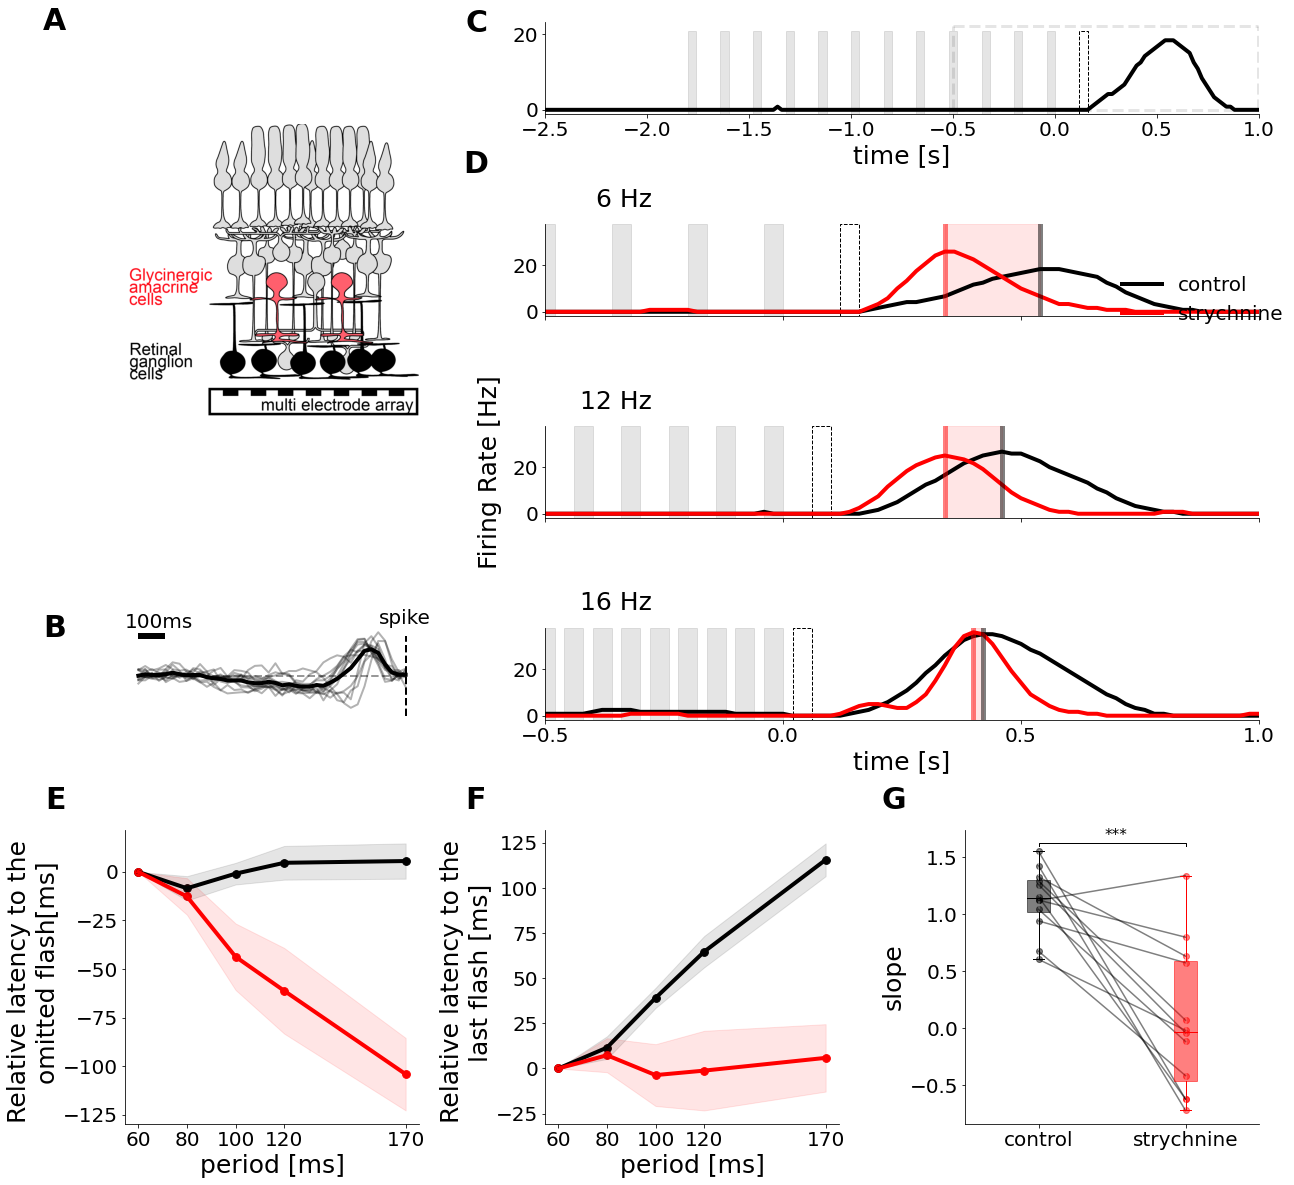

In [60]:
#figure parameter

fontsize_legend = 20
fontsize_labels = 25
fontsize_panellabel = 30
fontsize_ticks = 20
lw = 4
ms = 60
panellabel_position = [-0.2, 1.15]
frequencytext_position = [0.15,1.4]
nrows = 6
ncols = 6

figsize_ratio = 3



#initialize figure
fig = plt.figure(figsize=(ncols*figsize_ratio,nrows*figsize_ratio))
fig.patch.set_facecolor('white')


gs = fig.add_gridspec(nrows,ncols)
fig.tight_layout()



fig.subplots_adjust(top=0.9,
                    bottom=0.05,
                    left=0.1,
                    right=0.975,
                    hspace=1.2,
                    wspace=1.5)

#####################################################################################################################
# create panels
#####################################################################################################################


A = fig.add_subplot(gs[0:3,0:2], frameon = False)

B = fig.add_subplot(gs[3:4,0:2], frameon = False)

C = fig.add_subplot(gs[0:1,2:6])

D = fig.add_subplot(gs[1:4,2:6])

D0 = fig.add_subplot(gs[1,2:6])
D1 = fig.add_subplot(gs[2,2:6], sharey = D0, sharex = D0)
D2 = fig.add_subplot(gs[3,2:6], sharey = D0, sharex = D0)

E = fig.add_subplot(gs[4:nrows,0:2])
F = fig.add_subplot(gs[4:nrows,2:4])
G = fig.add_subplot(gs[4:nrows,4:6])



#####################################################################################################################
# PANEL A: scheme of the retina
#####################################################################################################################

if "A" in globals():
    ax = A
    #add panel labels
    ax.text(panellabel_position[0]-0.0,panellabel_position[1]+0.25, "A", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    #remove frames that are not needed
    ax.set_xticks([])
    ax.set_yticks([])

# #     ax.spines['left'].set_color('white')
# #     ax.tick_params(axis='y', colors='white')
# #     ax.tick_params(axis='x', colors='white')
# #     ax.spines['bottom'].set_color('white')

    ax.imshow(circuit_scheme)

#####################################################################################################################
# PANEL B: temporal STAs
#####################################################################################################################
if "B" in globals():
    ax = B
    panel = 'B'
    
    ax.text(*panellabel_position, panel, transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

    # 0 guide line
    ax.hlines(0,-1,0,
             color='k',
             linewidth = 2,
             linestyle = "--",
             alpha=.4)
    
    cells_with_sta = [key for key in cells_dict.keys() if key[:4] == 'cell']
    
    stas = np.zeros((len(cells_with_sta),40))
    
    for i_cell, cell in enumerate(cells_with_sta):
        ax.plot(np.linspace(-1,0,40),cells_dict[cell]['STA']['temporal'][:],
                   color='k',
                   alpha = .3,
                   linewidth = 2, label = f'_{cell}')
        print(cell)
        stas[i_cell,:] = cells_dict[cell]['STA']['temporal'][:]
            
    
    ax.plot(np.linspace(-1,0,40),np.mean(stas,axis=0),
                   color='k',
                   linewidth = 4, label = '_mean')
    
            
    # scale
    ax.hlines(0.5,-1,-0.9,
             color='k',
             linewidth = 6)
    ax.text(-1.05, 0.6, "100ms", fontsize = 20)
    
    # spike line
    ax.vlines(0,-0.5,0.5,
             color='k',
             linewidth = 2,
             linestyle = "--")
    ax.text(-0.1, 0.65, "spike", fontsize = 20)
    
    ax.set_xticks([])
    ax.set_yticks([])

    extract_source_data(ax,save_name,panel)    
#####################################################################################################################
# PANEL B (C0,C1,C2): OSR PSTHs at different frequencies
#####################################################################################################################

if "C" in globals():
    
    ax = C
    panel = 'C'
    #add panel label
    ax.text(panellabel_position[0]+0.12,panellabel_position[1]+0, panel, transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    
    ax.set_xlim(-2.5,1)



    # Label the axis
#     ax.set_ylabel('Firing Rate [Hz]',fontsize = fontsize_labels)
    ax.set_xlabel('time [s]',fontsize = fontsize_labels)
    
    ax.plot(times[0],responses_control[0], color = 'black', linewidth = lw, label='_control')


    # plot flashes
    for f in range(len(flashstarts[0])):   
        ax.axvspan(flashstarts[0][f], flashends[0][f], color = 'k', alpha = 0.1, ymax=.9)
    ax.axvspan(omitted_flashstarts[0], omitted_flashends[0], edgecolor = "k", facecolor="w", linestyle = '--', ymax=.9)

        
    plot_rectangle(ax,(-0.5,0),1.495,22,
                  alpha=.1, linewidth=3, )
    
    extract_source_data(ax,save_name,panel)    

        
#####################################################################################################################
# PANEL C (C0,C1,C2): OSR PSTHs at different frequencies
#####################################################################################################################


if "D" in globals():

    ax = D
    panel = "D"
    #add panel label
    ax.text(panellabel_position[0]+0.12,panellabel_position[1]+0, panel, transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.tick_params(axis='y', colors='white')
    ax.spines['bottom'].set_color('white')
    ax.tick_params(axis='x', colors='white')

    # Label the axis
    ax.set_ylabel('Firing Rate [Hz]',fontsize = fontsize_labels)
    ax.set_xlabel('time [s]',fontsize = fontsize_labels)
    


# SUBPANEL C0
#####################################################################################################################
if "D0" in globals():

    ax = D0
    panel = 'D0'
    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    ax.tick_params('x', labelbottom=False)


    # set axis range
    ax.set_xlim(-.5,1)

    # add frequency labels
    ax.text(*frequencytext_position, f'6 Hz', transform=ax.transAxes,
          fontsize=fontsize_labels, va='top', ha='right')

    # plot traces
    ax.plot(times[0],responses_control[0], color = 'black', linewidth = lw, label = 'control')
    ax.plot(times[0],responses_strychnine[0], color = 'red', linewidth = lw, label = 'strychnine')

    # plot flashes
    for f in range(len(flashstarts[0])):   
        ax.axvspan(flashstarts[0][f], flashends[0][f], color = 'k', alpha = 0.1)
    ax.axvspan(omitted_flashstarts[0], omitted_flashends[0], edgecolor = "k", facecolor="w", linestyle = '--')


    # peak timepoints
#     ax.scatter(delays_control[0],amps_control[0], color = 'k')
#     ax.scatter(delays_strychnine[0],amps_strychnine[0], color = 'red')

#     ax.axvline(delays_control[0], color = 'k', alpha = .5, linewidth = 5 )
#     ax.axvline(delays_strychnine[0], color = 'red', alpha = .5,linewidth = 5)

#     ax.axvspan(delays_control[0],delays_strychnine[0], color = 'red', alpha = 0.1)
#     ax.scatter(times[0][np.argmax(responses_control[0])],np.max(responses_control[0]), color = 'k')
#     ax.scatter(times[0][np.argmax(responses_strychnine[0])],np.max(responses_strychnine[0]), color = 'red')

    ax.axvline(times[0][np.argmax(responses_control[0])], color = 'k', alpha = .5, linewidth = 5 )
    ax.axvline(times[0][np.argmax(responses_strychnine[0])], color = 'red', alpha = .5,linewidth = 5)

    ax.axvspan(times[0][np.argmax(responses_control[0])],times[0][np.argmax(responses_strychnine[0])], color = 'r', alpha = 0.1)

    extract_source_data(ax,save_name,panel)   
    #testax = ax
 

# SUBPANEL C1
#####################################################################################################################
if "D1" in globals():

    ax = D1
    panel = 'D1'
    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.tick_params('x', labelbottom=False)
    # add frequency labels
    ax.text(*frequencytext_position, f'12 Hz', transform=ax.transAxes,
            fontsize=fontsize_labels, va='top', ha='right')

    # plot traces
    ax.plot(times[1],responses_control[1], color = 'black', linewidth = lw, label = '_control')
    ax.plot(times[1],responses_strychnine[1], color = 'red', linewidth = lw, label = '_strychnine')

    # plot flashes
    for f in range(len(flashstarts[0])):   
        ax.axvspan(flashstarts[1][f], flashends[1][f], color = 'k', alpha = 0.1)
    ax.axvspan(omitted_flashstarts[1], omitted_flashends[1], edgecolor = "k", facecolor="w", linestyle = '--')


    # peak timepoints
#     ax.scatter(delays_control[1],amps_control[1], color = 'k')
#     ax.scatter(delays_strychnine[1],amps_strychnine[1], color = 'red')

#     ax.axvline(delays_control[1], color = 'k', alpha = .5, linewidth = 5 )
#     ax.axvline(delays_strychnine[1], color = 'red', alpha = .5,linewidth = 5)

#     ax.axvspan(delays_control[1],delays_strychnine[1], color = 'red', alpha = 0.1)

#     ax.scatter(times[1][np.argmax(responses_control[1])],np.max(responses_strychnine[1]), color = 'k')
#     ax.scatter(times[1][np.argmax(responses_strychnine[1])],np.max(responses_strychnine[1]), color = 'red')

    ax.axvline(times[1][np.argmax(responses_control[1])], color = 'k', alpha = .5, linewidth = 5 )
    ax.axvline(times[1][np.argmax(responses_strychnine[1])], color = 'red', alpha = .5,linewidth = 5)

    ax.axvspan(times[1][np.argmax(responses_control[1])],times[1][np.argmax(responses_strychnine[1])], color = 'r', alpha = 0.1)
    extract_source_data(ax,save_name,panel)   




# SUBPANEL C2
#####################################################################################################################
if "D2" in globals():

    ax = D2
    panel = 'D2'
    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.locator_params(axis='x', nbins=3)
    # add frequency labels

    ax.text(*frequencytext_position, f'16 Hz', transform=ax.transAxes,
          fontsize=fontsize_labels, va='top', ha='right')

    # plot traces
    ax.plot(times[2],responses_control[2], color = 'black', linewidth = lw, label = '_control')
    ax.plot(times[2],responses_strychnine[2], color = 'red', linewidth = lw, label = '_strychnine')

    # plot flashes
    for f in range(len(flashstarts[0])):   
        ax.axvspan(flashstarts[2][f], flashends[2][f], color = 'k', alpha = 0.1)
    ax.axvspan(omitted_flashstarts[2], omitted_flashends[2], edgecolor = "k", facecolor="w", linestyle = '--')


    # peak timepoints
#     ax.scatter(delays_control[2],amps_control[2], color = 'k')
#     ax.scatter(delays_strychnine[2],amps_strychnine[2], color = 'red')

#     ax.axvline(delays_control[2], color = 'k', alpha = .5, linewidth = 5 )
#     ax.axvline(delays_strychnine[2], color = 'red', alpha = .5,linewidth = 5)

#     ax.axvspan(delays_control[2],delays_strychnine[2], color = 'red', alpha = 0.1)
#     ax.scatter(times[2][np.argmax(responses_control[2])],np.max(responses_strychnine[2]), color = 'k')
#     ax.scatter(times[2][np.argmax(responses_strychnine[2])],np.max(responses_strychnine[2]), color = 'red')

    ax.axvline(times[2][np.argmax(responses_control[2])], color = 'k', alpha = .5, linewidth = 5 )
    ax.axvline(times[2][np.argmax(responses_strychnine[2])], color = 'red', alpha = .5,linewidth = 5)

    ax.axvspan(times[2][np.argmax(responses_control[2])],times[2][np.argmax(responses_strychnine[2])], color = 'r', alpha = 0.1)

    extract_source_data(ax,save_name,panel)    

#####################################################################################################################
# PANEL E: quantificaiton of slope for one cell
#####################################################################################################################

if "E" in globals():

    ax = E
    panel = 'E'
    #add panel label
    ax.text(*panellabel_position, "E", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    #
    ax.locator_params(axis='x', nbins=3)
    
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)


    # Label the axis
    ax.set_ylabel('Relative latency to the \n omitted flash[ms]',fontsize = fontsize_labels)
    ax.set_xlabel('period [ms]',fontsize = fontsize_labels)
    
    ax.set_xticks(all_periods[::-1])

    ax.plot(all_periods,delays_control_mean_OS,color = 'black',linewidth = lw, label = '_control')
    ax.scatter(all_periods,delays_control_mean_OS, color = 'black', s = ms)

    ax.plot(all_periods,delays_strychnine_mean_OS,color = 'red',linewidth = lw, label = '_strychnine')
    ax.scatter(all_periods,delays_strychnine_mean_OS, color = 'red', s = ms)


    # std data
    ax.fill_between(all_periods,delays_control_mean_OS-delays_control_std_OS, delays_control_mean_OS+delays_control_std_OS, alpha = 0.1, color = 'black')
    ax.fill_between(all_periods,delays_strychnine_mean_OS-delays_strychnine_std_OS, delays_strychnine_mean_OS+delays_strychnine_std_OS, alpha = 0.1, color = 'red')
    extract_source_data(ax,save_name,panel)    



#####################################################################################################################
# PANEL E: quantification of slope for all cells
#####################################################################################################################
if "F" in globals():

    ax = F
    panel = 'F'
    #add panel label
    ax.text(*panellabel_position, "F", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')
    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    #
    ax.locator_params(axis='x', nbins=3)

    # Label the axis
    ax.set_ylabel('Relative latency to the \n last flash [ms]',fontsize = fontsize_labels)
    ax.set_xlabel('period [ms]',fontsize = fontsize_labels)
    
    ax.set_xticks(all_periods[::-1])
    
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)


    # plot data
    ax.plot(all_periods,delays_control_mean,color = 'black',linewidth = lw, label = '_control')
    ax.scatter(all_periods,delays_control_mean, color = 'black', s = ms)

    ax.plot(all_periods,delays_strychnine_mean,color = 'red',linewidth = lw, label = '_strychnine')
    ax.scatter(all_periods,delays_strychnine_mean, color = 'red', s = ms)


    # std data
    ax.fill_between(all_periods,delays_control_mean-delays_control_std, delays_control_mean+delays_control_std, alpha = 0.1, color = 'black')
    ax.fill_between(all_periods,delays_strychnine_mean-delays_strychnine_std, delays_strychnine_mean+delays_strychnine_std, alpha = 0.1, color = 'red')

    extract_source_data(ax,save_name,panel)    


#####################################################################################################################
# PANEL F: quantification of slopes in a boxplot
#####################################################################################################################

if "G" in globals():

    ax = G
    panel = 'G'
    #add panel label
    ax.text(*panellabel_position, "G", transform=ax.transAxes,
          fontsize=fontsize_panellabel, fontweight='bold', va='top', ha='right')

    #remove frames that are not needed
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    # Label the axis
    ax.set_ylabel('slope',fontsize = fontsize_labels)
    
    
    ax.set_xticklabels(["control", "strychnine"])
    
    ax.plot(np.ones(len(all_slopes_control)),all_slopes_control, color = 'w', alpha = 0.5, label = '_control')
    ax.plot(np.ones(len(all_slopes_strychnine))*2,all_slopes_strychnine, color = 'w', alpha = 0.5, label = '_strychnine')

    ax.scatter(np.ones(len(all_slopes_control)),all_slopes_control, color = 'k', alpha = 0.5, label = '_control')
    ax.scatter(np.ones(len(all_slopes_strychnine))*2,all_slopes_strychnine, color = 'r', alpha = 0.5, label = '_strychnine')
    
  
    for i,di in enumerate(all_slopes_control):
        plt.plot([1,2], [di,all_slopes_strychnine[i]], color = 'k', alpha = 0.5)
    
    # plot data
    ax.boxplot(all_slopes_control,
                    patch_artist=True,
                    positions = [1],
                    boxprops=dict(facecolor='black', color='black', alpha = 0.5),
                    capprops=dict(color='black'),
                    whiskerprops=dict(color='black'),
                    flierprops=dict(color='black', markeredgecolor='black'),
                    medianprops=dict(color='black'),
                    )

    ax.boxplot(all_slopes_strychnine,
                    patch_artist=True,
                    positions = [2],
                    boxprops=dict(facecolor='red', color='red', alpha = 0.5),
                    capprops=dict(color='red'),
                    whiskerprops=dict(color='red'),
                    flierprops=dict(color='red', markeredgecolor='red'),
                    medianprops=dict(color='red'),
                    )
    
    ax.plot([1,1,2,2], [1.6,1.62,1.62,1.6], color='k', linewidth=1)
    ax.annotate("***",(1.45,1.65), fontsize=15)
    
for ax in [A,B,C,D0,D1,D2,D,E,F,G]:
    ax.tick_params('x', labelsize=fontsize_ticks)
    ax.tick_params('y', labelsize=fontsize_ticks)

    extract_source_data(ax,save_name,panel)    

#### Figure
# print label
fig.legend(fontsize = fontsize_legend, frameon=False,loc=(.86,.72))


if save:
    plt.savefig("../Figures/{}.{}".format(save_name, image_format), dpi=dpi)
if show:
    plt.show()
else:
    plt.close()

In [23]:
mean_control = np.mean(all_slopes_control)
sem_control = np.std(all_slopes_control)/np.sqrt(len(all_slopes_control))

mean_strych = np.mean(all_slopes_strychnine)
sem_strych = np.std(all_slopes_strychnine)/np.sqrt(len(all_slopes_strychnine))

In [24]:
print(f'OSR slope control (mean, SEM): {mean_control:.2f},{sem_control:.2f}')
print(f'OSR slope strychnine (mean, SEM): {mean_strych:.2f},{sem_strych:.2f}')

OSR slope control (mean, SEM): 1.13,0.08
OSR slope strychnine (mean, SEM): 0.07,0.18


In [40]:
testlines = testax.get_lines()
for line in testlines:
    print(line.get_label())
    


control
strychnine
_line2
_line3


In [45]:
test = ax.get_lines()

In [53]:
for line in test:
    print(line.get_label())

_line0
_line1
_line2
_line3
_line4
_line5
_line6
_line7
_line8
_line9
_line10
_line11
_line12
_line13
_line14
_line15
_line16
_line17
_line18
_line19
_line20
_line21
_line22
_line23
_line24


In [17]:
def extract_source_data(ax):
    lines = ax.get_lines()

    source_data = pd.DataFrame()
    for i,line in enumerate(lines):

        lab = line.get_label()
        x = line.get_xdata()
        y = line.get_ydata()
        df[f'{lab}_x'] = x
        df[f'{lab}_y'] = y

        return df
   